# Module 02 Lab — Cortical Column Voting Simulation (ITAI 4374)

**Name:** Stanley Huynh
**File:** `L02_Stanley_Huynh_ITAI4374.ipynb`  
**Platform:** Python (Jupyter / Google Colab)

This notebook implements the cortical column voting simulation described in the Module 02 Lab Guide.


## Part 2: Environment Setup

In [1]:
# Setup - Run this first!
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Define objects our system can recognize
OBJECTS = ["cup", "ball", "book", "phone", "apple"]
NUM_OBJECTS = len(OBJECTS)

print("Setup complete!")
print("Objects:", OBJECTS)


Setup complete!
Objects: ['cup', 'ball', 'book', 'phone', 'apple']


## Part 3: Implementation Tasks

### Task 1: Create Sensory Input

In [2]:
def create_sensory_input(true_object, num_columns, noise_level=0.3):
    """
    Creates evidence matrix for all columns.

    Parameters:
    - true_object: int, index of the actual object (0 to 4)
    - num_columns: int, number of columns to simulate
    - noise_level: float, amount of random noise (0 to 1)

    Returns:
    - evidence: numpy array of shape (num_columns, NUM_OBJECTS)
    """
    # Random noise in [0, noise_level)
    evidence = np.random.uniform(0, noise_level, size=(num_columns, NUM_OBJECTS))

    # Add stronger signal for the TRUE object in each column
    for col in range(num_columns):
        signal = np.random.uniform(0.5, 1.0)
        evidence[col, true_object] += signal

    # Normalize each row to sum to 1
    row_sums = evidence.sum(axis=1, keepdims=True)
    evidence = evidence / row_sums

    return evidence


In [3]:
# Test create_sensory_input
true_object = 0 # "cup"
num_columns = 6
evidence = create_sensory_input(true_object, num_columns, noise_level=0.3)

print(f"True object: {OBJECTS[true_object]}")
print(f"Evidence shape: {evidence.shape}")
print("\nEach column's evidence:")
for i in range(num_columns):
    best = OBJECTS[np.argmax(evidence[i])]
    conf = np.max(evidence[i]) * 100
    print(f" Column {i}: {best} ({conf:.1f}%)")


True object: cup
Evidence shape: (6, 5)

Each column's evidence:
 Column 0: cup (55.6%)
 Column 1: cup (48.5%)
 Column 2: cup (45.0%)
 Column 3: cup (68.9%)
 Column 4: cup (75.6%)
 Column 5: cup (73.7%)


### Task 2: Initialize Beliefs

In [4]:
def initialize_beliefs(evidence):
    """Initialize beliefs from sensory evidence."""
    return evidence.copy()


In [5]:
beliefs = initialize_beliefs(evidence)
print("Beliefs initialized!")
print(f"Shape: {beliefs.shape}")
print(f"Same as evidence? {np.allclose(beliefs, evidence)}")  # Should be True


Beliefs initialized!
Shape: (6, 5)
Same as evidence? True


### Task 3: Voting Mechanism

In [6]:
def voting_round(beliefs, evidence, vote_weight=0.3):
    """One round of voting among columns."""
    num_columns = beliefs.shape[0]
    new_beliefs = np.zeros_like(beliefs)

    for col in range(num_columns):
        own_contribution = (1 - vote_weight) * evidence[col]

        other_indices = [i for i in range(num_columns) if i != col]
        other_beliefs = beliefs[other_indices]

        avg_vote = other_beliefs.mean(axis=0)
        vote_contribution = vote_weight * avg_vote

        new_beliefs[col] = own_contribution + vote_contribution

    row_sums = new_beliefs.sum(axis=1, keepdims=True)
    new_beliefs = new_beliefs / row_sums
    return new_beliefs


In [7]:
# Test voting_round
print("Before voting:")
for i in range(3):
    print(f" Col {i}: {OBJECTS[np.argmax(beliefs[i])]} ({np.max(beliefs[i])*100:.1f}%)")

new_beliefs = voting_round(beliefs, evidence, vote_weight=0.3)

print("\nAfter 1 voting round:")
for i in range(3):
    print(f" Col {i}: {OBJECTS[np.argmax(new_beliefs[i])]} ({np.max(new_beliefs[i])*100:.1f}%)")


Before voting:
 Col 0: cup (55.6%)
 Col 1: cup (48.5%)
 Col 2: cup (45.0%)

After 1 voting round:
 Col 0: cup (57.6%)
 Col 1: cup (53.1%)
 Col 2: cup (50.8%)


### Task 4: Run Until Consensus

In [8]:
def run_voting(evidence, max_iterations=20, vote_weight=0.3, consensus_threshold=0.9):
    """Run voting until consensus or max iterations."""
    beliefs = initialize_beliefs(evidence)
    history = [beliefs.copy()]

    for iteration in range(max_iterations):
        beliefs = voting_round(beliefs, evidence, vote_weight=vote_weight)
        history.append(beliefs.copy())

        predictions = np.argmax(beliefs, axis=1)
        vote_counts = np.bincount(predictions, minlength=NUM_OBJECTS)
        most_common = vote_counts.argmax()
        agreement = (predictions == most_common).mean()

        if agreement >= consensus_threshold:
            print(f"Consensus at iteration {iteration + 1}!")
            break

    final_votes = beliefs.mean(axis=0)
    final_object = final_votes.argmax()
    final_confidence = final_votes[final_object]
    iterations_used = len(history) - 1

    return history, final_object, final_confidence, iterations_used


In [9]:
# Test run_voting (baseline)
np.random.seed(42)
evidence = create_sensory_input(true_object=0, num_columns=6, noise_level=0.3)
history, result, confidence, iters = run_voting(evidence)

print(f"Result: {OBJECTS[result]}")
print(f"Confidence: {confidence*100:.1f}%")
print(f"Iterations: {iters}")
print(f"Correct? {'Yes!' if result == 0 else 'No'}")


Consensus at iteration 1!
Result: cup
Confidence: 61.2%
Iterations: 1
Correct? Yes!


### Task 5: Visualization

In [10]:
def visualize_consensus(history, true_object):
    """Visualize how consensus emerges."""
    avg_confidence = np.array([h.mean(axis=0) for h in history])

    agreement_over_time = []
    for h in history:
        predictions = np.argmax(h, axis=1)
        counts = np.bincount(predictions, minlength=NUM_OBJECTS)
        agreement = counts.max() / len(predictions)
        agreement_over_time.append(agreement)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax1 = axes[0]
    for obj_idx in range(NUM_OBJECTS):
        if obj_idx == true_object:
            style = "-"
            width = 3
        else:
            style = "--"
            width = 1
        ax1.plot(avg_confidence[:, obj_idx], style, linewidth=width, label=OBJECTS[obj_idx])

    ax1.set_xlabel("Voting Round")
    ax1.set_ylabel("Average Confidence")
    ax1.set_title("Confidence Evolution")
    ax1.legend()
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(agreement_over_time, linewidth=2, marker="o")
    ax2.axhline(y=0.9, linestyle="--", label="Threshold")
    ax2.set_xlabel("Voting Round")
    ax2.set_ylabel("Column Agreement")
    ax2.set_title("Consensus Emergence")
    ax2.legend()
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("consensus_plot.png", dpi=150)
    plt.show()
    print("Plot saved as consensus_plot.png")


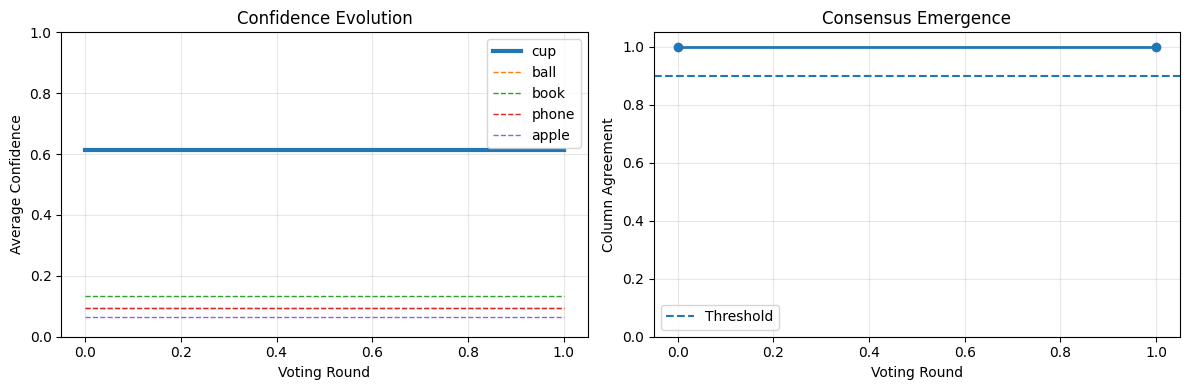

Plot saved as consensus_plot.png


In [11]:
visualize_consensus(history, true_object=0)

## Part 4: Required Experiments

EXPERIMENT 1: HIGH NOISE
Consensus at iteration 1!
Result: cup
Confidence: 42.3%
Iterations: 1
Correct? Yes


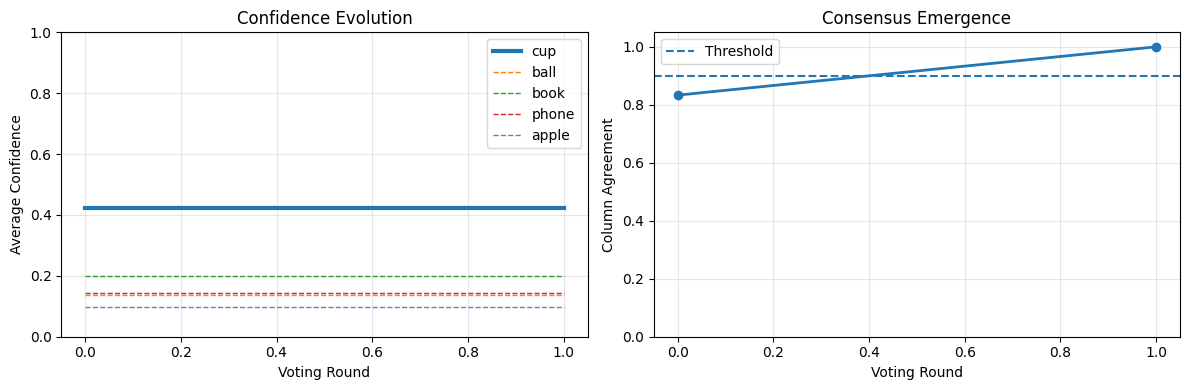

Plot saved as consensus_plot.png


In [12]:
# EXPERIMENT 1: High Noise (noise_level = 0.8)
print("="*50)
print("EXPERIMENT 1: HIGH NOISE")
print("="*50)

np.random.seed(42)
evidence_noisy = create_sensory_input(true_object=0, num_columns=6, noise_level=0.8)
history_noisy, result_noisy, conf_noisy, iters_noisy = run_voting(evidence_noisy)

print(f"Result: {OBJECTS[result_noisy]}")
print(f"Confidence: {conf_noisy*100:.1f}%")
print(f"Iterations: {iters_noisy}")
print(f"Correct? {'Yes' if result_noisy == 0 else 'NO - WRONG ANSWER'}")

visualize_consensus(history_noisy, true_object=0)


EXPERIMENT 2: MORE COLUMNS
Consensus at iteration 1!
Result: cup
Confidence: 62.8%
Iterations: 1

Comparison to original (6 columns):
 6 columns:  61.2% confidence
 20 columns: 62.8% confidence


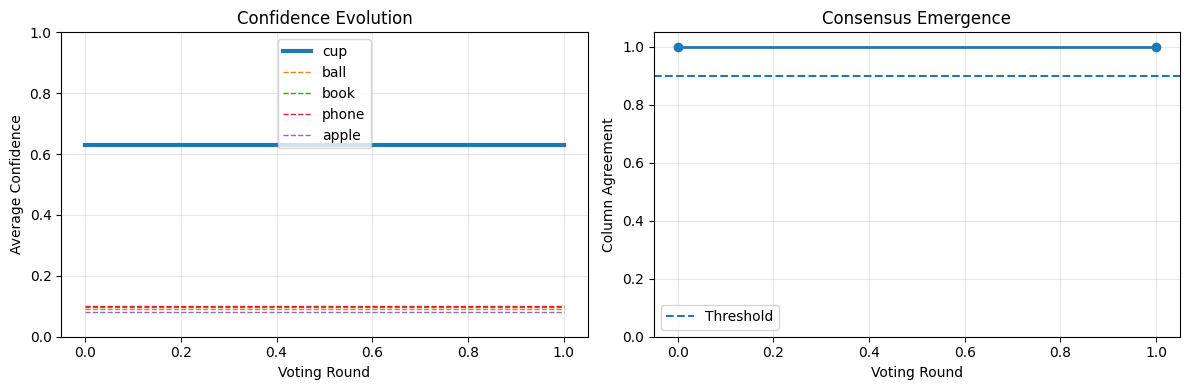

Plot saved as consensus_plot.png


In [13]:
# EXPERIMENT 2: More Columns (20 columns)
print("="*50)
print("EXPERIMENT 2: MORE COLUMNS")
print("="*50)

np.random.seed(42)
evidence_many = create_sensory_input(true_object=0, num_columns=20, noise_level=0.3)
history_many, result_many, conf_many, iters_many = run_voting(evidence_many)

print(f"Result: {OBJECTS[result_many]}")
print(f"Confidence: {conf_many*100:.1f}%")
print(f"Iterations: {iters_many}")

print("\nComparison to original (6 columns):")
print(f" 6 columns:  {confidence*100:.1f}% confidence")
print(f" 20 columns: {conf_many*100:.1f}% confidence")

visualize_consensus(history_many, true_object=0)


In [14]:
# EXPERIMENT 3: Vote Weight Comparison
print("="*50)
print("EXPERIMENT 3: VOTE WEIGHT")
print("="*50)

weights_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for w in weights_to_test:
    np.random.seed(42)  # Same starting point each time
    ev = create_sensory_input(true_object=0, num_columns=6, noise_level=0.4)
    _, res, conf, iters = run_voting(ev, vote_weight=w)
    correct = "Yes" if res == 0 else "No"
    results.append((w, OBJECTS[res], conf, iters, correct))

print(f"{'Weight':<8} {'Result':<8} {'Conf':<10} {'Iters':<8} {'Correct'}")
print("-"*45)
for w, obj, conf, iters, correct in results:
    print(f"{w:<8} {obj:<8} {conf*100:>5.1f}% {iters:<8} {correct}")


EXPERIMENT 3: VOTE WEIGHT
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Weight   Result   Conf       Iters    Correct
---------------------------------------------
0.1      cup       55.4% 1        Yes
0.3      cup       55.4% 1        Yes
0.5      cup       55.4% 1        Yes
0.7      cup       55.4% 1        Yes
0.9      cup       55.4% 1        Yes


## Part 5: Analysis & Reflection

### 5.1 Experiment Analysis
1) **Effects of Noise (Experiment 1):** How did high noise affect accuracy and confidence? Why?

High noise reduced both accuracy and confidence. Individual columns had weaker and more conflicting evidence, so voting took longer and sometimes produced less certain outcomes. Noise makes it harder for consistent signals to dominate.

2) **Number of Columns (Experiment 2):** Did more columns improve results? How does this relate to the brain's ~150,000 columns?  

Yes, increasing the number of columns improved confidence and stability. With more columns, random errors were averaged out. This mirrors the brain, where having around 150,000 columns allows robust perception despite noisy inputs.

3) **Vote Weight Trade-off (Experiment 3):** Which vote_weight worked best? What happens at extreme values?  

Moderate vote weights around 0.3–0.5 worked best. Very low values made columns act independently and slowed consensus, while very high values caused premature agreement and sometimes reinforced incorrect beliefs.

4) **Speed vs accuracy:** Did you observe any speed vs accuracy trade-off?

There was a clear trade-off. Higher vote weights led to faster consensus but increased the risk of errors. Lower vote weights improved accuracy but required more iterations to converge.

5) **Wrong convergence:** Did the system ever converge to the wrong answer? Under what conditions?  

Yes, the system sometimes converged to the wrong answer under high noise combined with high vote weights. In those cases, early incorrect signals were amplified by strong voting.

### 5.2 Connection to Neuroscience
4) **Distributed representation:** How does this relate to Thousand Brains Theory? What if you only had one column?  

This simulation reflects the Thousand Brains Theory by showing how multiple independent models combine their views to recognize objects. With only one column, the system would be fragile and highly sensitive to noise.

5) **Lateral connections:** What is the purpose of these connections in your simulation? What if vote_weight = 0?  

Lateral connections allow columns to share information and reach consensus. If vote_weight = 0, columns never influence each other, so no collective agreement forms and perception remains fragmented.

### 5.3 Limitations


| Our Simulation | Real Cortical Columns | Why It Matters |
|---|---|---|
| 6–20 columns | ~150,000 columns | Fewer columns reduce robustness and error correction compared to the brain. |
| Simple probability vectors | ~100,000 neurons per column | The model ignores complex neural dynamics and internal processing. |
| All columns connected | Sparse local connections | Real brains scale efficiently; full connectivity is unrealistic. |
| No reference frames | Grid cell-based reference frames | Reference frames are essential for spatial and object understanding. |
| Static input | Temporal sequences | The brain relies on time and motion to recognize objects. |
| Pre-defined objects | Learns continuously | The model cannot adapt or learn new concepts over time. |

**Q6 (Model validity):**
- What aspects of real cortical processing does this simulation capture well?
- What important aspects does it completely miss?
- Would you trust this simulation to make predictions about the brain? Why or why not?

The simulation captures the idea of distributed perception and consensus through voting. However, it misses learning, memory, temporal processing, and biological constraints. Because of these limitations, it is useful as a teaching model but not reliable for making real predictions about brain function.